In [1]:
import os,sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('/home/xiaodongli/dingjch/projects/CMASSmock_cosmoAI/HAM_selection/library')
import geometry as geo

In [2]:
def divide_no_zero(x, y):
    # return x/y if y!=0; otherwise 0; 
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(y==0, 0.0, x/y)

In [3]:
res_PS = pd.DataFrame(np.loadtxt('analytic.dat',skiprows=2), columns=['sigma', 'f(sigma)', 'Mh', 'dn/dlogM'])

In [4]:
# >>> 1. sim-parameters
fid_w   = -1.0
fid_om  = 0.26
fid_h   = 0.71

sim_label      = 'COLASim_w-1.0om0.2951h0.6881_z0.5000-dz0.05_FR0.265-TotalRvir'
FidCosmo_label = 'FidCos_w{:.1f}'.format(fid_w) +'om{:.4f}'.format(fid_om)+'h{:.4f}'.format(fid_h)

Mbin = 50
Mh_type = 'Mvir'
logMh_range = np.linspace(15.06, 12.16, Mbin+1)
print(logMh_range)

[15.06  15.002 14.944 14.886 14.828 14.77  14.712 14.654 14.596 14.538
 14.48  14.422 14.364 14.306 14.248 14.19  14.132 14.074 14.016 13.958
 13.9   13.842 13.784 13.726 13.668 13.61  13.552 13.494 13.436 13.378
 13.32  13.262 13.204 13.146 13.088 13.03  12.972 12.914 12.856 12.798
 12.74  12.682 12.624 12.566 12.508 12.45  12.392 12.334 12.276 12.218
 12.16 ]


In [5]:
gsnap_path = '/home/xiaodongli/data/CITAData/RockstarHalo_MergerTree/simHtree_FR0.265/'
gsnap_file = 'censubH_tree_snapz0.5000_FR0.265_TotalRvir.xyzvxvyvz_mvir_mpeak_vmax_vpeak_pid'

simH_gadg = pd.DataFrame(np.loadtxt(gsnap_path+gsnap_file), 
                         columns=['X', 'Y', 'Z', 'Vx', 'Vy', 'Vz', 'Mvir', 'Mpeak', 'Vmax', 'Vpeak', 'pid'])

print(simH_gadg.columns)


simH_gadg['logMh'] = np.log10(simH_gadg['Mvir'])  # log10(M_sun/h)
print(np.max(simH_gadg['logMh']), np.min(simH_gadg['logMh']))


Index(['X', 'Y', 'Z', 'Vx', 'Vy', 'Vz', 'Mvir', 'Mpeak', 'Vmax', 'Vpeak',
       'pid'],
      dtype='object')
15.024485667699167 12.182699903336042


In [6]:
csnap_path = '/home/xiaodongli/dingjch/projects/Simulation_cosmoAI/800box_1024npar_TestCosmo/Zinit_sameda/Zinit-029/simHtree_FR0.265_da1-120/'
csnap_file = 'censubH_tree_snapz0.5000_FR0.265_TotalRvir.xyzvxvyvz_mvir_mpeak_vmax_vpeak_pid'

simH_cola = pd.DataFrame(np.loadtxt(csnap_path+csnap_file), 
                         columns=['X', 'Y', 'Z', 'Vx', 'Vy', 'Vz', 'Mvir', 'Mpeak', 'Vmax', 'Vpeak', 'pid'])

print(simH_cola.columns)
simH_cola['logMh'] = np.log10(simH_cola['Mvir'])  # log10(M_sun/h)
print(np.max(simH_cola['logMh']), np.min(simH_cola['logMh']))


Index(['X', 'Y', 'Z', 'Vx', 'Vy', 'Vz', 'Mvir', 'Mpeak', 'Vmax', 'Vpeak',
       'pid'],
      dtype='object')
15.066325925362039 12.176958980586909


In [7]:
V_box = 800**3 # (Mpc/h)^3

In [8]:
len(simH_cola)/V_box

0.001755078125

In [9]:
logMh_bin = []; 
HMF_gadg  = []
for i in range(Mbin):
    numH_gadg = len(simH_gadg.query('{:.4f}'.format(logMh_range[i])+'>logMh>={:.4f}'.format(logMh_range[i+1])))
    HMF_gadg.append(numH_gadg/(logMh_range[i]-logMh_range[i+1])/V_box)
    logMh_bin.append(np.mean([logMh_range[i], logMh_range[i+1]]))
logMh_bin = np.array(logMh_bin)
HMF_gadg = np.array(HMF_gadg)

In [10]:
logMh_bin = []; 
HMF_cola = []
for i in range(Mbin):
    numH_cola = len(simH_cola.query('{:.4f}'.format(logMh_range[i])+'>logMh>={:.4f}'.format(logMh_range[i+1])))
    HMF_cola.append(numH_cola/(logMh_range[i]-logMh_range[i+1])/V_box)
    logMh_bin.append(np.mean([logMh_range[i], logMh_range[i+1]]))

logMh_bin = np.array(logMh_bin)
HMF_cola  = np.array(HMF_cola)

(5e-08, 0.01)

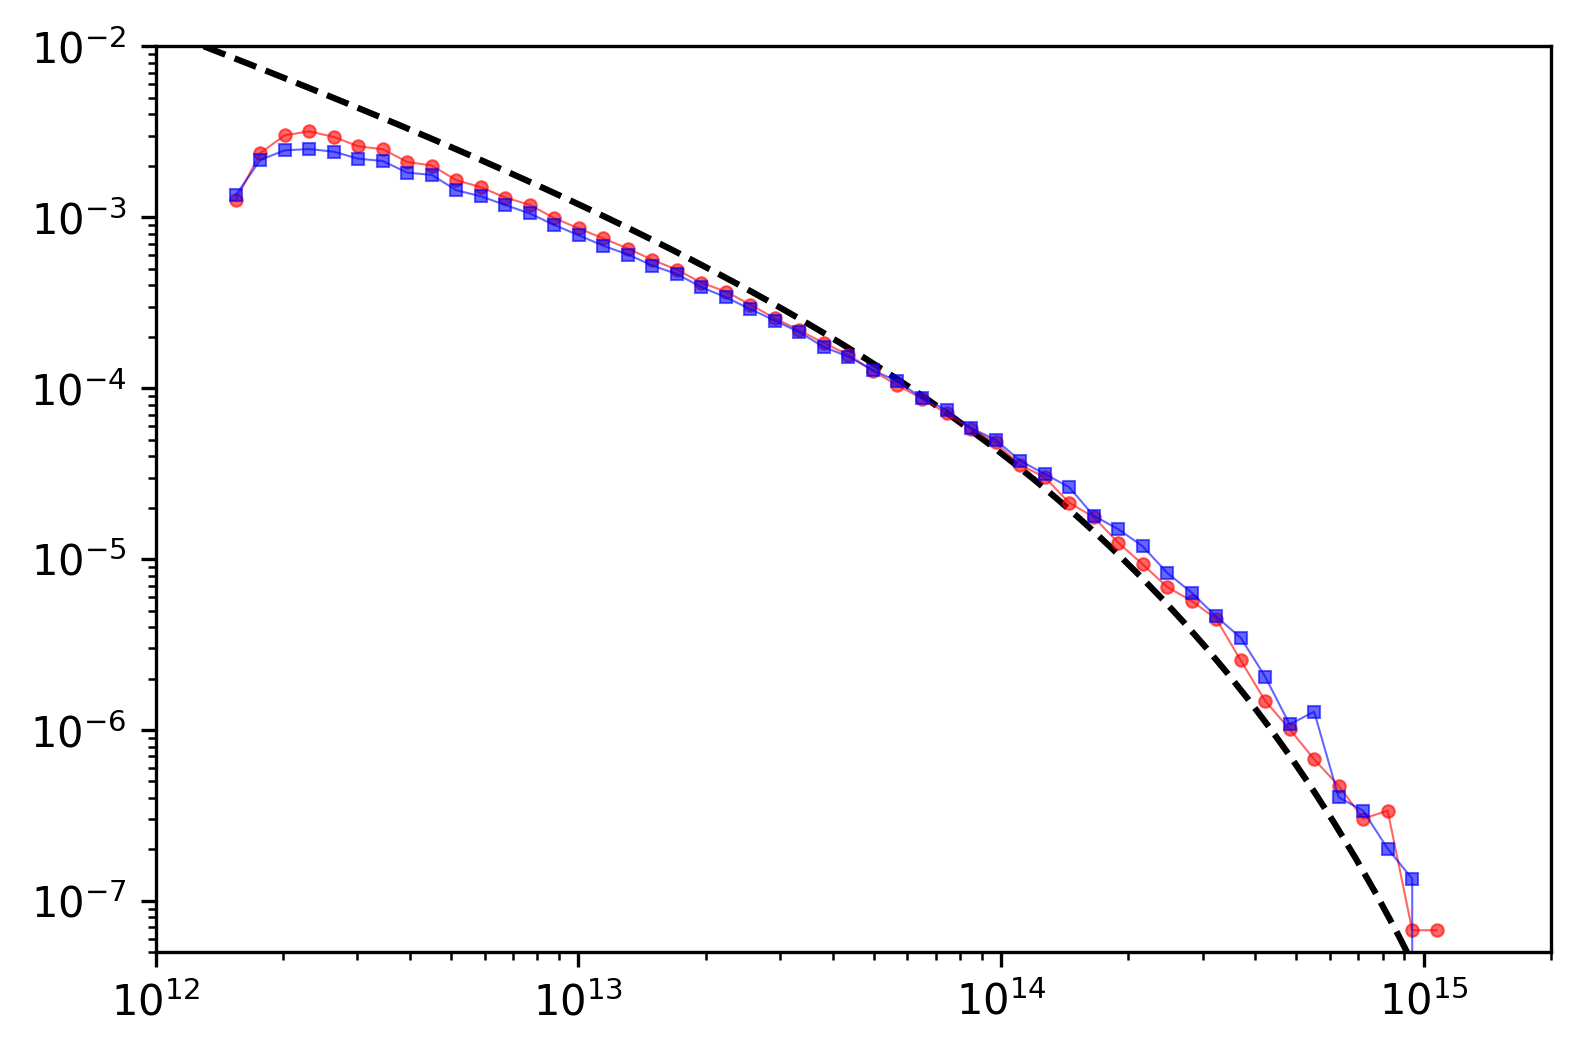

In [11]:
plt.figure(dpi=300)

plt.plot(res_PS['Mh'], res_PS['dn/dlogM'], '--', color='black')

plt.plot(10**logMh_bin, HMF_gadg, 'ro-', ms=3, mew=0.5, lw=0.5, alpha=0.6)
plt.plot(10**logMh_bin, HMF_cola, 'bs-', ms=3, mew=0.5, lw=0.5, alpha=0.6)
plt.xscale('log')
plt.yscale('log')

plt.xlim(1e12, 2e15)
plt.ylim(5e-8, 1e-2)

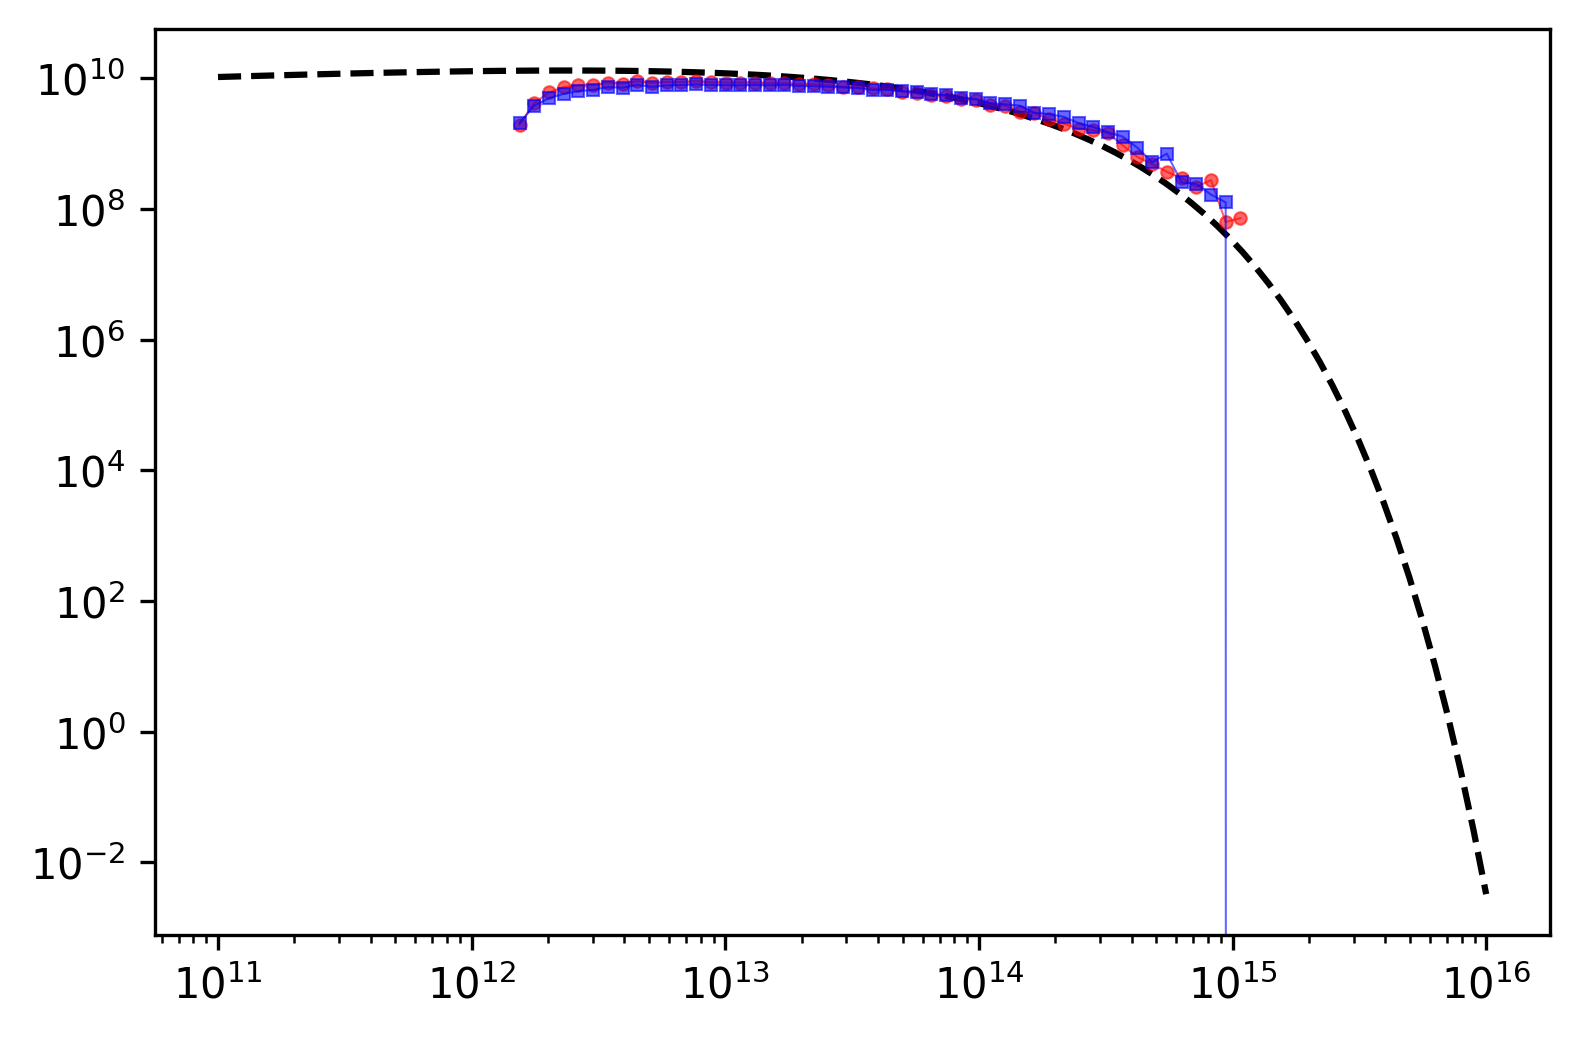

In [12]:
plt.figure(dpi=300)
plt.plot(res_PS['Mh'], res_PS['Mh']*res_PS['dn/dlogM'], '--', color='black')

plt.plot(10**logMh_bin, (10**logMh_bin)**1*HMF_gadg, 'ro-', ms=3, mew=0.5, lw=0.5, alpha=0.6)
plt.plot(10**logMh_bin, (10**logMh_bin)**1*HMF_cola, 'bs-', ms=3, mew=0.5, lw=0.5, alpha=0.6)
plt.xscale('log')
plt.yscale('log')

#plt.xlim(1e12, 2e15)
#plt.ylim(5e-8, 5e-2)

In [13]:
line_list  = ['-', '-.', '--', ':']
mark_list  = ['^', 's', 'd', 'h']
color_list = ['dodgerblue', 'limegreen', 'orange','dimgrey']

type_list = ['diffZinit_da=1/Nstep', 'sameZinit_da=1/120', 'Zinit-29_da=1/Nstep']


fig = plt.figure(figsize=(6,12), dpi=300)
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.direction'] = 'inout'
plt.rcParams['ytick.direction'] = 'inout'
plt.rcParams['text.usetex'] = False


gs = fig.add_gridspec(nrows=3, ncols=1, hspace=0, height_ratios=(1,1,1))

ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[2,0])

ax0.plot(res_PS['Mh'], res_PS['dn/dlogM'], '--', color='black', lw=1, label = '     ')
ax1.plot(res_PS['Mh'], res_PS['dn/dlogM'], '--', color='black', lw=1, label = '     ')
ax2.plot(res_PS['Mh'], res_PS['dn/dlogM'], '--', color='black', lw=1, label = '     ')

ax0.plot(10**logMh_bin, HMF_gadg, 'ro-', ms=3, mew=0.5, lw=0.5, alpha=0.6, 
         label = '     ')
         #label='GADGET mock')
ax1.plot(10**logMh_bin, HMF_gadg, 'ro-', ms=3, mew=0.5, lw=0.5, alpha=0.6, 
         label = '     ')
         #label='GADGET mock')
ax2.plot(10**logMh_bin, HMF_gadg, 'ro-', ms=3, mew=0.5, lw=0.5, alpha=0.6, 
         label = '     ')
         #label='GADGET mock')

    
for sim_type in type_list:
    
    if sim_type == 'diffZinit_da=1/Nstep':
        Zinit_list = [  29,   59,  119,  49]
        Nstep_list = [  30,   60,  120,  50]
        sim_path   = '/home/xiaodongli/dingjch/projects/Simulation_cosmoAI/800box_1024npar_TestCosmo/'+\
                     '891_ranseed6000_om0.2951_omb0.0468_oml0.7049_w-1.0000_Hubble0.6881_sig80.8000_ns0.9600'
    elif sim_type=='sameZinit_da=1/120':
        Zinit_list = [  29,   59,  119]
        sim_path   = '/home/xiaodongli/dingjch/projects/Simulation_cosmoAI/800box_1024npar_TestCosmo/Zinit_sameda'  
    elif sim_type=='Zinit-29_da=1/Nstep':
        Zinit_list = [  29,   29,   29]
        Nstep_list = [  30,   60,  120]
        sim_path   = '/home/xiaodongli/dingjch/projects/Simulation_cosmoAI/800box_1024npar_TestCosmo/Zinit_sameda'
    else:
        sys.exit() 

            
    for isim in range(len(Zinit_list)):
        if sim_type == 'diffZinit_da=1/Nstep':
            simH_path = os.path.join(sim_path, 'simHtree_FR0.265_sp{:>03d}/'.format(Nstep_list[isim]))
        elif sim_type=='sameZinit_da=1/120':
            simH_path = os.path.join(sim_path, 'Zinit-{:>03d}/simHtree_FR0.265_da1-120/'.format(Zinit_list[isim]))
        elif sim_type=='Zinit-29_da=1/Nstep':
            simH_path = os.path.join(sim_path, 'Zinit-029/simHtree_FR0.265_da1-{:>03d}/'.format(Nstep_list[isim]))
        
        #HAM_label = 'HAM-'+HAM_variable+'-sig{:.2f}'.format(sigma_list[isim])
        #simH_file = sim_label+'__'+FidCosmo_label+'__'+HAM_label+'__censubH_cmass.csv'
        print(simH_path+simH_file)
        simH_file = 'censubH_tree_snapz0.5000_FR0.265_TotalRvir.xyzvxvyvz_mvir_mpeak_vmax_vpeak_pid'
        simH = pd.DataFrame(np.loadtxt(simH_path+simH_file), 
                            columns=['X', 'Y', 'Z', 'Vx', 'Vy', 'Vz', 'Mvir', 'Mpeak', 'Vmax', 'Vpeak', 'pid'])

        simH['logMh'] = np.log10(simH[Mh_type])  # log10(M_sun/h)
        print(np.max(simH['logMh']), np.min(simH['logMh']))

        HMF = []
        for i in range(Mbin):
            numH = len(simH.query('{:.4f}'.format(logMh_range[i])+'>logMh>={:.4f}'.format(logMh_range[i+1])))
            HMF.append(numH/V_box/(logMh_range[i]-logMh_range[i+1])) 
        HMF = np.array(HMF)



        if sim_type == 'diffZinit_da=1/Nstep':
            #label = r'$N_{step}$'+'={:> 3d}'.format(Nstep_list[isim])+\
            #        r', $\sigma^{\rm best}_{\rm scat}$'+'={:.2f}'.format(sigma_list[isim])
            label = '     '
            
            ax0.plot(10**logMh_bin, HMF, mark_list[isim]+line_list[isim], color=color_list[isim], 
                     ms=3, mew=0.5, mfc='none', lw=0.5, label=label)
        
        elif sim_type == 'sameZinit_da=1/120':
            #label = r'$z_{init}$'+'={:> 3d}'.format(Zinit_list[isim])+\
            #        r', $\sigma^{\rm best}_{\rm scat}$'+'={:.2f}'.format(sigma_list[isim])
            label = '     '
            ax1.plot(10**logMh_bin, HMF, mark_list[isim]+line_list[isim], color=color_list[isim], 
                     ms=3, mew=0.5, mfc='none', lw=0.5, label=label)
            
        elif sim_type == 'Zinit-29_da=1/Nstep':
            #label = r'$N_{step}$'+'={:> 3d}'.format(Nstep_list[isim])+\
            #        r', $\sigma^{\rm best}_{\rm scat}$'+'={:.2f}'.format(sigma_list[isim])
            label = '     '
            ax2.plot(10**logMh_bin, HMF, mark_list[isim]+line_list[isim], color=color_list[isim], 
                     ms=3, mew=0.5, mfc='none', lw=0.5, label=label)


ax0.set_ylabel(r'$ dn\,/\,d{\rm log}M_{h} \;\; (h^{3}\,{\rm Mpc^{-3}})$')
ax1.set_ylabel(r'$ dn\,/\,d{\rm log}M_{h} \;\; (h^{3}\,{\rm Mpc^{-3}})$')
ax2.set_ylabel(r'$ dn\,/\,d{\rm log}M_{h} \;\; (h^{3}\,{\rm Mpc^{-3}})$')

ax2.set_xlabel(r'$ M_{\rm h} \;\; (h^{-1}\,M_{\odot})$')

ax0.set_xscale('log')
ax0.set_yscale('log')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_xscale('log')
ax2.set_yscale('log')


ax0.set_xlim(1e12, 1e15)
ax1.set_xlim(1e12, 1e15)
ax2.set_xlim(1e12, 1e15)

ax0.set_ylim(3e-7, 2e-2)
ax1.set_ylim(3e-7, 2e-2)
ax2.set_ylim(3e-7, 2e-2)

ax0.xaxis.set_ticklabels([])
ax1.xaxis.set_ticklabels([])

ax1_ = ax1.twiny()
ax1_.set_xlim(1e12, 1e15)
ax1_.set_xscale('log')
ax1_.xaxis.set_ticklabels([])

ax2_ = ax2.twiny()
ax2_.set_xlim(1e12, 1e15)
ax2_.set_xscale('log')
ax2_.xaxis.set_ticklabels([])

#ax0.yaxis.set_ticklabels([])
#ax1.yaxis.set_ticklabels([])
#ax2.yaxis.set_ticklabels([])


ax0.legend(loc='lower left', frameon=False, fontsize=14, handlelength=1.2)
ax1.legend(loc='lower left', frameon=False, fontsize=14, handlelength=1.2)
ax2.legend(loc='lower left', frameon=False, fontsize=14, handlelength=1.2)


ax0.tick_params(axis='x', width=1.0, length=5, which='major')
ax0.tick_params(axis='x', width=0.7, length=3, which='minor')
ax0.tick_params(axis='y', width=1.0, length=5, which='major')
ax0.tick_params(axis='y', width=0.7, length=3, which='minor')
ax1.tick_params(axis='x', width=1.0, length=5, which='major')
ax1.tick_params(axis='x', width=0.7, length=3, which='minor')
ax1.tick_params(axis='y', width=1.0, length=5, which='major')
ax1.tick_params(axis='y', width=0.7, length=3, which='minor')
ax2.tick_params(axis='x', width=1.0, length=5, which='major')
ax2.tick_params(axis='x', width=0.7, length=3, which='minor')
ax2.tick_params(axis='y', width=1.0, length=5, which='major')
ax2.tick_params(axis='y', width=0.7, length=3, which='minor')

ax1_.tick_params(axis='x', width=1.0, length=5, which='major')
ax1_.tick_params(axis='x', width=0.7, length=3, which='minor')
ax2_.tick_params(axis='x', width=1.0, length=5, which='major')
ax2_.tick_params(axis='x', width=0.7, length=3, which='minor')

/home/xiaodongli/dingjch/projects/Simulation_cosmoAI/800box_1024npar_TestCosmo/891_ranseed6000_om0.2951_omb0.0468_oml0.7049_w-1.0000_Hubble0.6881_sig80.8000_ns0.9600/simHtree_FR0.265_sp030/censubH_tree_snapz0.5000_FR0.265_TotalRvir.xyzvxvyvz_mvir_mpeak_vmax_vpeak_pid
15.045714058940868 12.176958980586909
/home/xiaodongli/dingjch/projects/Simulation_cosmoAI/800box_1024npar_TestCosmo/891_ranseed6000_om0.2951_omb0.0468_oml0.7049_w-1.0000_Hubble0.6881_sig80.8000_ns0.9600/simHtree_FR0.265_sp060/censubH_tree_snapz0.5000_FR0.265_TotalRvir.xyzvxvyvz_mvir_mpeak_vmax_vpeak_pid
15.068556895072364 12.176958980586909
/home/xiaodongli/dingjch/projects/Simulation_cosmoAI/800box_1024npar_TestCosmo/891_ranseed6000_om0.2951_omb0.0468_oml0.7049_w-1.0000_Hubble0.6881_sig80.8000_ns0.9600/simHtree_FR0.265_sp120/censubH_tree_snapz0.5000_FR0.265_TotalRvir.xyzvxvyvz_mvir_mpeak_vmax_vpeak_pid
15.042575512440191 12.176958980586909
/home/xiaodongli/dingjch/projects/Simulation_cosmoAI/800box_1024npar_TestCosmo/891

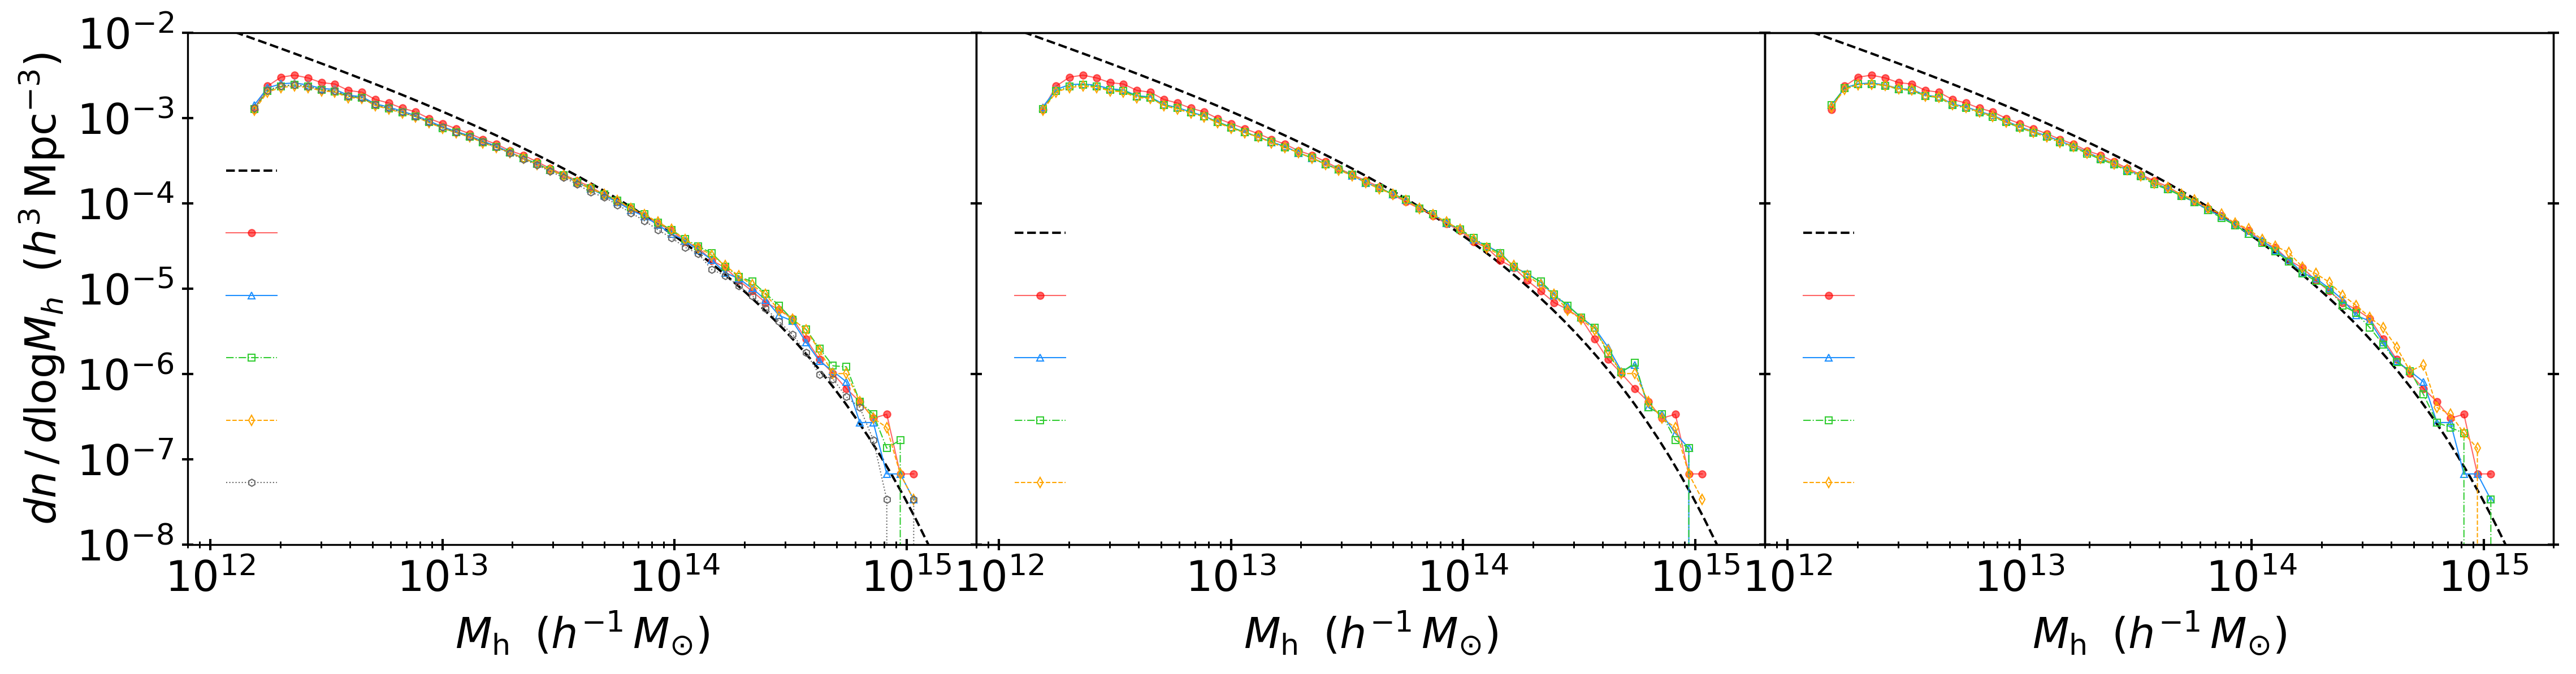

In [31]:
type_list = ['diffZinit_da=1/Nstep', 'sameZinit_da=1/120', 'Zinit-29_da=1/Nstep']


fig = plt.figure(figsize=(18,4), dpi=300)
plt.rcParams['font.size'] = 18
plt.rcParams['xtick.direction'] = 'inout'
plt.rcParams['ytick.direction'] = 'inout'
plt.rcParams['text.usetex'] = False


gs = fig.add_gridspec(nrows=1, ncols=3, wspace=0)

ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[0,2])

ax0.plot(res_PS['Mh'], res_PS['dn/dlogM'], '--', color='black', lw=1, label = '     ')
ax1.plot(res_PS['Mh'], res_PS['dn/dlogM'], '--', color='black', lw=1, label = '     ')
ax2.plot(res_PS['Mh'], res_PS['dn/dlogM'], '--', color='black', lw=1, label = '     ')

ax0.plot(10**logMh_bin, HMF_gadg, 'ro-', ms=3, mew=0.5, lw=0.5, alpha=0.6, 
         label = '     ')
         #label='GADGET mock')
ax1.plot(10**logMh_bin, HMF_gadg, 'ro-', ms=3, mew=0.5, lw=0.5, alpha=0.6, 
         label = '     ')
         #label='GADGET mock')
ax2.plot(10**logMh_bin, HMF_gadg, 'ro-', ms=3, mew=0.5, lw=0.5, alpha=0.6, 
         label = '     ')
         #label='GADGET mock')

    
for sim_type in type_list:
    
    if sim_type == 'diffZinit_da=1/Nstep':
        Zinit_list = [  29,   59,  119,  49]
        Nstep_list = [  30,   60,  120,  50]
        sim_path   = '/home/xiaodongli/dingjch/projects/Simulation_cosmoAI/800box_1024npar_TestCosmo/'+\
                     '891_ranseed6000_om0.2951_omb0.0468_oml0.7049_w-1.0000_Hubble0.6881_sig80.8000_ns0.9600'
    elif sim_type=='sameZinit_da=1/120':
        Zinit_list = [  29,   59,  119]
        sim_path   = '/home/xiaodongli/dingjch/projects/Simulation_cosmoAI/800box_1024npar_TestCosmo/Zinit_sameda'  
    elif sim_type=='Zinit-29_da=1/Nstep':
        Zinit_list = [  29,   29,   29]
        Nstep_list = [  30,   60,  120]
        sim_path   = '/home/xiaodongli/dingjch/projects/Simulation_cosmoAI/800box_1024npar_TestCosmo/Zinit_sameda'
    else:
        sys.exit() 

            
    for isim in range(len(Zinit_list)):
        if sim_type == 'diffZinit_da=1/Nstep':
            simH_path = os.path.join(sim_path, 'simHtree_FR0.265_sp{:>03d}/'.format(Nstep_list[isim]))
        elif sim_type=='sameZinit_da=1/120':
            simH_path = os.path.join(sim_path, 'Zinit-{:>03d}/simHtree_FR0.265_da1-120/'.format(Zinit_list[isim]))
        elif sim_type=='Zinit-29_da=1/Nstep':
            simH_path = os.path.join(sim_path, 'Zinit-029/simHtree_FR0.265_da1-{:>03d}/'.format(Nstep_list[isim]))
        
        #HAM_label = 'HAM-'+HAM_variable+'-sig{:.2f}'.format(sigma_list[isim])
        #simH_file = sim_label+'__'+FidCosmo_label+'__'+HAM_label+'__censubH_cmass.csv'
        
        simH_file = 'censubH_tree_snapz0.5000_FR0.265_TotalRvir.xyzvxvyvz_mvir_mpeak_vmax_vpeak_pid'
        print(simH_path+simH_file)
        simH = pd.DataFrame(np.loadtxt(simH_path+simH_file), 
                            columns=['X', 'Y', 'Z', 'Vx', 'Vy', 'Vz', 'Mvir', 'Mpeak', 'Vmax', 'Vpeak', 'pid'])

        simH['logMh'] = np.log10(simH[Mh_type])  # log10(M_sun/h)
        print(np.max(simH['logMh']), np.min(simH['logMh']))

        HMF = []
        for i in range(Mbin):
            numH = len(simH.query('{:.4f}'.format(logMh_range[i])+'>logMh>={:.4f}'.format(logMh_range[i+1])))
            HMF.append(numH/V_box/(logMh_range[i]-logMh_range[i+1])) 
        HMF = np.array(HMF)



        if sim_type == 'diffZinit_da=1/Nstep':
            #label = r'$N_{step}$'+'={:> 3d}'.format(Nstep_list[isim])+\
            #        r', $\sigma^{\rm best}_{\rm scat}$'+'={:.2f}'.format(sigma_list[isim])
            label = '     '
            
            ax0.plot(10**logMh_bin, HMF, mark_list[isim]+line_list[isim], color=color_list[isim], 
                     ms=3, mew=0.5, mfc='none', lw=0.5, label=label)
        
        elif sim_type == 'sameZinit_da=1/120':
            #label = r'$z_{init}$'+'={:> 3d}'.format(Zinit_list[isim])+\
            #        r', $\sigma^{\rm best}_{\rm scat}$'+'={:.2f}'.format(sigma_list[isim])
            label = '     '
            ax1.plot(10**logMh_bin, HMF, mark_list[isim]+line_list[isim], color=color_list[isim], 
                     ms=3, mew=0.5, mfc='none', lw=0.5, label=label)
            
        elif sim_type == 'Zinit-29_da=1/Nstep':
            #label = r'$N_{step}$'+'={:> 3d}'.format(Nstep_list[isim])+\
            #        r', $\sigma^{\rm best}_{\rm scat}$'+'={:.2f}'.format(sigma_list[isim])
            label = '     '
            ax2.plot(10**logMh_bin, HMF, mark_list[isim]+line_list[isim], color=color_list[isim], 
                     ms=3, mew=0.5, mfc='none', lw=0.5, label=label)


ax0.set_ylabel(r'$ dn\,/\,d{\rm log}M_{h} \;\; (h^{3}\,{\rm Mpc^{-3}})$')
#ax1.set_ylabel(r'$ dn\,/\,d{\rm log}M_{h} \;\; (h^{3}\,{\rm Mpc^{-3}})$')
#ax2.set_ylabel(r'$ dn\,/\,d{\rm log}M_{h} \;\; (h^{3}\,{\rm Mpc^{-3}})$')

ax0.set_xlabel(r'$ M_{\rm h} \;\; (h^{-1}\,M_{\odot})$')
ax1.set_xlabel(r'$ M_{\rm h} \;\; (h^{-1}\,M_{\odot})$')
ax2.set_xlabel(r'$ M_{\rm h} \;\; (h^{-1}\,M_{\odot})$')

ax0.set_xscale('log')
ax0.set_yscale('log')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax2.set_xscale('log')
ax2.set_yscale('log')


ax0.set_xlim(8e11, 2e15)
ax1.set_xlim(8e11, 2e15)
ax2.set_xlim(8e11, 2e15)

ax0.set_ylim(1e-8, 1e-2)
ax0.set_yticks([1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2])


ax1.set_ylim(1e-8, 1e-2)
ax2.set_ylim(1e-8, 1e-2)

ax1.yaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])

ax1_ = ax1.twinx()
ax1_.set_ylim(1e-8, 1e-2)
ax1_.set_yscale('log')
ax1_.yaxis.set_ticklabels([])

ax2_ = ax2.twinx()
ax2_.set_ylim(1e-8, 1e-2)
ax2_.set_yscale('log')
ax2_.yaxis.set_ticklabels([])

#ax0.yaxis.set_ticklabels([])
#ax1.yaxis.set_ticklabels([])
#ax2.yaxis.set_ticklabels([])

ax0.legend(loc='lower left', frameon=False, fontsize=18, handlelength=1.2)
ax1.legend(loc='lower left', frameon=False, fontsize=18, handlelength=1.2)
ax2.legend(loc='lower left', frameon=False, fontsize=18, handlelength=1.2)


ax0.tick_params(axis='x', width=1.0, length=5, which='major')
ax0.tick_params(axis='x', width=0.7, length=3, which='minor')
ax0.tick_params(axis='y', width=1.0, length=5, which='major')
ax0.tick_params(axis='y', width=0.7, length=3, which='minor')
ax1.tick_params(axis='x', width=1.0, length=5, which='major')
ax1.tick_params(axis='x', width=0.7, length=3, which='minor')
ax1.tick_params(axis='y', width=1.0, length=5, which='major')
ax1.tick_params(axis='y', width=0.7, length=3, which='minor')
ax2.tick_params(axis='x', width=1.0, length=5, which='major')
ax2.tick_params(axis='x', width=0.7, length=3, which='minor')
ax2.tick_params(axis='y', width=1.0, length=5, which='major')
ax2.tick_params(axis='y', width=0.7, length=3, which='minor')

ax1_.tick_params(axis='y', width=1.0, length=5, which='major')
ax1_.tick_params(axis='y', width=0.7, length=3, which='minor')
ax2_.tick_params(axis='y', width=1.0, length=5, which='major')
ax2_.tick_params(axis='y', width=0.7, length=3, which='minor')